In [1]:
using Turing, MCMCChains, Distributions, RData, CSV, XLSX, DataFrames, LinearAlgebra, StatsFuns, Random, Serialization, CairoMakie, AlgebraOfGraphics, Plots, StatsPlots, Gadfly, KernelDensity
using AlgebraOfGraphics:density
using DataFrames:stack
using CairoMakie:violin
using Plots
using Colors  

dir = "/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Fertility/ModellingF/Output/"

chain_model1f1 = deserialize(dir * "chain_model1f1.jls")
chain_model1f2 = deserialize(dir * "chain_model1f2.jls")
chain_model1f3 = deserialize(dir * "chain_model1f3.jls")
chain_model1f4 = deserialize(dir * "chain_model1f4.jls")
chain_model2f = deserialize(dir * "chain_model2f.jls")
chain_model3f = deserialize(dir * "chain_model3f.jls")

chains = [
    chain_model1f1,
    chain_model1f2,
    chain_model1f3,
    chain_model1f4,
    chain_model2f,
    chain_model3f] 

6-element Vector{Chains{Float64, AxisArrays.AxisArray{Float64, 3, Array{Float64, 3}, Tuple{AxisArrays.Axis{:iter, StepRange{Int64, Int64}}, AxisArrays.Axis{:var, Vector{Symbol}}, AxisArrays.Axis{:chain, UnitRange{Int64}}}}, Missing, @NamedTuple{parameters::Vector{Symbol}, internals::Vector{Symbol}}, @NamedTuple{varname_to_symbol::OrderedCollections.OrderedDict{AbstractPPL.VarName, Symbol}, start_time::Float64, stop_time::Float64}}}:
 MCMC chain (1000×179×1 Array{Float64, 3})
 MCMC chain (1000×179×1 Array{Float64, 3})
 MCMC chain (1000×179×1 Array{Float64, 3})
 MCMC chain (1000×179×1 Array{Float64, 3})
 MCMC chain (1000×662×1 Array{Float64, 3})
 MCMC chain (1000×578×1 Array{Float64, 3})

In [ ]:
#Goodness-of-Fit (Graph)

In [2]:
lmu = deserialize("/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Fertility/ModellingF/Data_Created/lmu.jls")
lcp = deserialize("/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Fertility/ModellingF/Data_Created/lcparameters.jls")

Dict{Any, Any} with 12 entries:
  5  => Dict{Any, Any}(4=>[-2.28396 -1.74328 … -2.86083 -3.08058; -2.74744 -2.1…
  7  => Dict{Any, Any}(4=>[-2.4257 -2.52986 … -2.70049 -2.62449; -2.75618 -2.86…
  12 => Dict{Any, Any}(4=>[-2.51414 -2.48683 … -2.29562 -2.57762; -2.47308 -2.4…
  8  => Dict{Any, Any}(4=>[-2.51386 -2.48668 … -2.29565 -2.57765; -2.47356 -2.4…
  1  => Dict{Any, Any}(4=>[-2.28379 -1.74335 … -2.86067 -3.07857; -2.7474 -2.15…
  4  => Dict{Any, Any}(4=>[-2.51473 -2.48684 … -2.29595 -2.57778; -2.47386 -2.4…
  6  => Dict{Any, Any}(4=>[-2.2174 -2.11829 … -2.54985 -2.5117; -2.73126 -2.638…
  11 => Dict{Any, Any}(4=>[-2.42611 -2.53008 … -2.7007 -2.62446; -2.75634 -2.86…
  2  => Dict{Any, Any}(4=>[-2.21709 -2.11801 … -2.54973 -2.51142; -2.73039 -2.6…
  10 => Dict{Any, Any}(4=>[-2.21715 -2.11812 … -2.54969 -2.51127; -2.73055 -2.6…
  9  => Dict{Any, Any}(4=>[-2.28337 -1.74301 … -2.85838 -3.07866; -2.74731 -2.1…
  3  => Dict{Any, Any}(4=>[-2.42607 -2.52996 … -2.70052 -2.62446; -2.75643 -2

In [10]:
using MCMCChains
using Plots
using Colors
using DataFrames
using Statistics

function plot_goodness_of_fit(chain, param_logmu::String, df::DataFrame, column_index::Int, ylims::Tuple{Float64, Float64}=(-Inf, Inf))
    # Setup the age group labels and color gradient
    age_groups_labels = ["25-29", "30-34", "35-39", "40-44", "45-49", "50-54"]
    n_groups_age = length(age_groups_labels)
    colors_age = cgrad(:cividis, n_groups_age, categorical=true)

    # Verify DataFrame has the required column
    if column_index > size(df, 2)
        error("Column index $column_index is out of bounds for the given DataFrame")
    end

    # Check if the parameter exists in the chain
    if !any(occursin(param_logmu, string(s)) for s in names(chain))
        error("Parameter pattern $param_logmu not found in the chain")
    end

    # Extract data for each specified index in logmu for the 21st year
    logmu_data = [chain[Symbol("$param_logmu[$i,21]")].data for i in 1:n_groups_age]
    column_21_data = df[!, column_index]

    # Plot configuration with y-axis limits
    logmu_plot = Plots.plot(xlabel="Age Groups", ylabel=L"\log(\mu)", xticks=(1:n_groups_age, age_groups_labels), xrotation=60, legend=false, grid=false, ylim=ylims)

    # Adding violin and scatter plots for each age group
    for (i, samples) in enumerate(logmu_data)
        Plots.violin!(logmu_plot, [i for _ in 1:length(samples)], samples, label=nothing, width=0.5, whisker_width=0.1, alpha=0.6, color=colors_age[i])
        mean_value = mean(samples)
        Plots.scatter!(logmu_plot, [i], [mean_value], color=:black, markersize=4, label=nothing)
    end

    # Adding red dots from DataFrame for observed values
    Plots.scatter!(logmu_plot, 1:n_groups_age, column_21_data, color=:red, markersize=5, label=nothing)

    # Display the plot
    return logmu_plot
end


plot_goodness_of_fit (generic function with 2 methods)

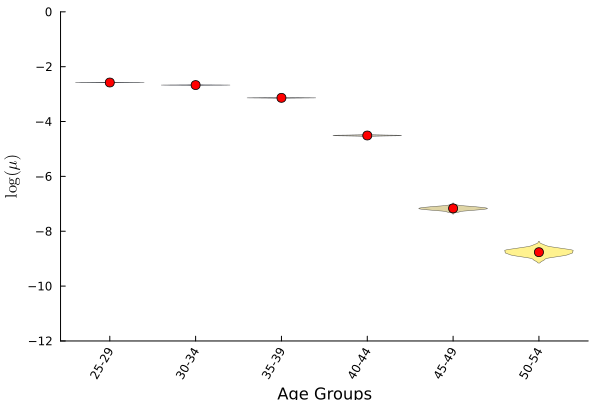

In [11]:
gofmodelA1 = plot_goodness_of_fit(chain_model1f1, "logmu", lmu[1], 21, (-12.0, 0.0) )
gofmodelA2 = plot_goodness_of_fit(chain_model1f2, "logmu", lmu[2], 21, (-12.0, 0.0) )
gofmodelA3 = plot_goodness_of_fit(chain_model1f3, "logmu", lmu[3], 21, (-12.0, 0.0) )
gofmodelA4 = plot_goodness_of_fit(chain_model1f4, "logmu", lmu[4], 21, (-12.0, 0.0) )

gofmodelB1 = plot_goodness_of_fit(chain_model2f, "logmu1", lmu[1], 21, (-12.0, 0.0) )
gofmodelB2 = plot_goodness_of_fit(chain_model2f, "logmu2", lmu[2], 21, (-12.0, 0.0) )
gofmodelB3 = plot_goodness_of_fit(chain_model2f, "logmu3", lmu[3], 21, (-12.0, 0.0) )
gofmodelB4 = plot_goodness_of_fit(chain_model2f, "logmu4", lmu[4], 21, (-12.0, 0.0) )

gofmodelC1 = plot_goodness_of_fit(chain_model3f, "logmu1", lmu[1], 21, (-12.0, 0.0) )
gofmodelC2 = plot_goodness_of_fit(chain_model3f, "logmu2", lmu[2], 21, (-12.0, 0.0) )
gofmodelC3 = plot_goodness_of_fit(chain_model3f, "logmu3", lmu[3], 21, (-12.0, 0.0) )
gofmodelC4 = plot_goodness_of_fit(chain_model3f, "logmu4", lmu[4], 21, (-12.0, 0.0) )

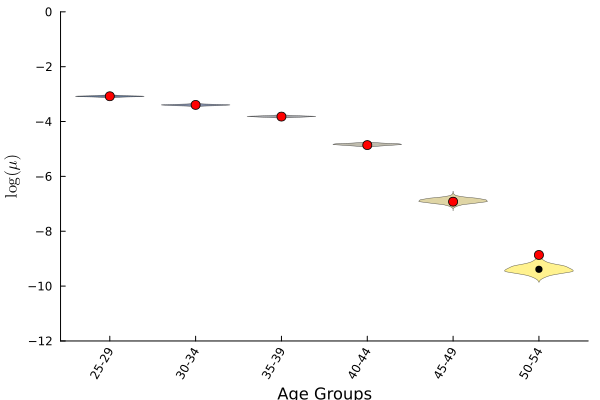

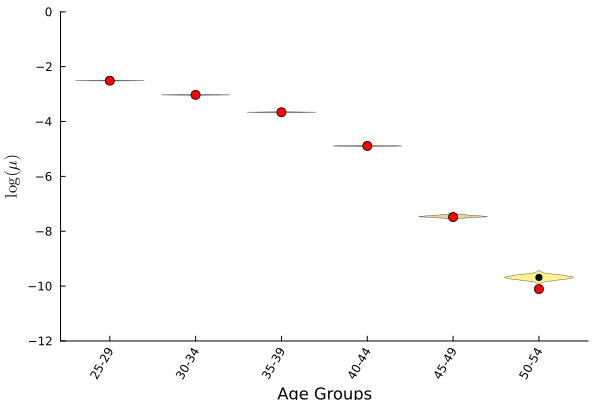

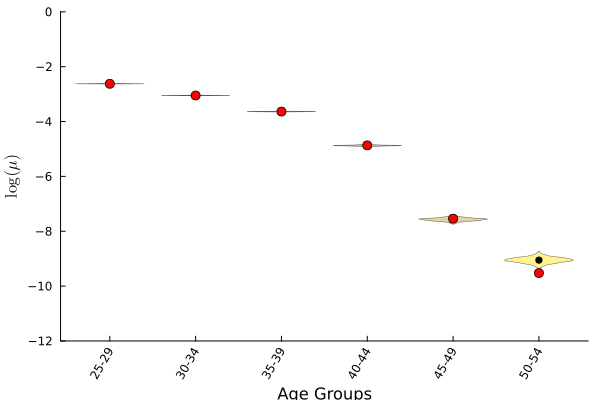

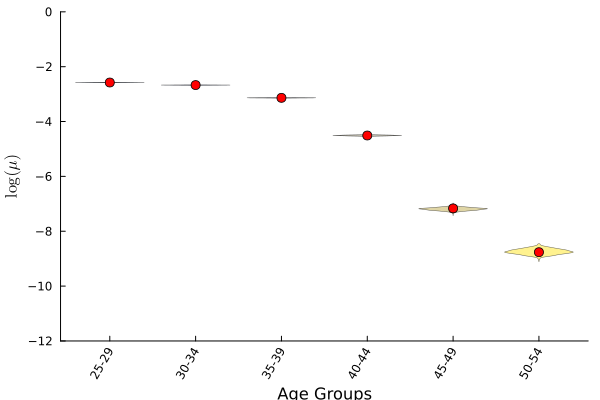

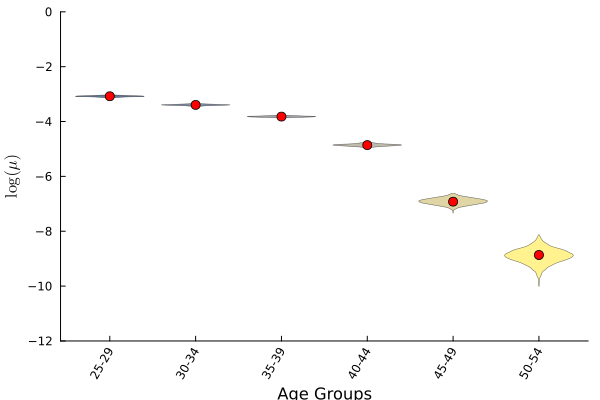

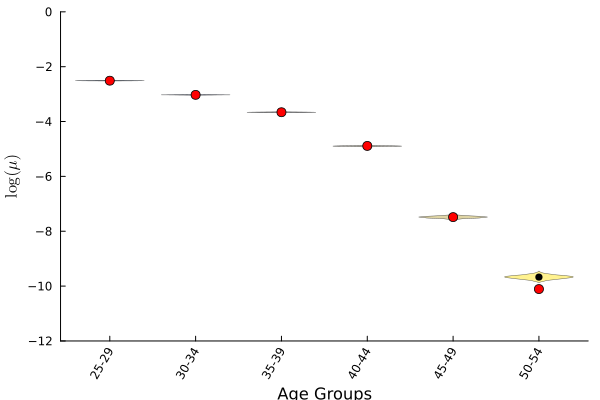

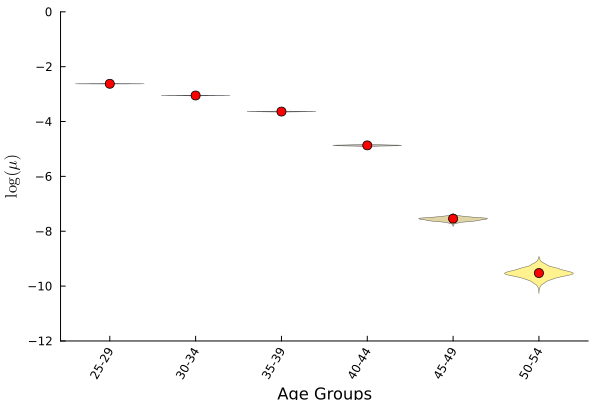

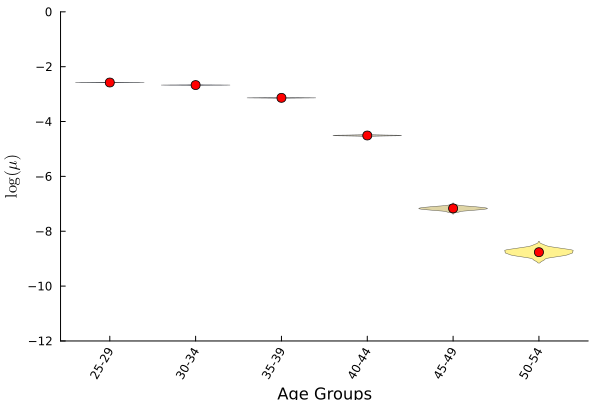

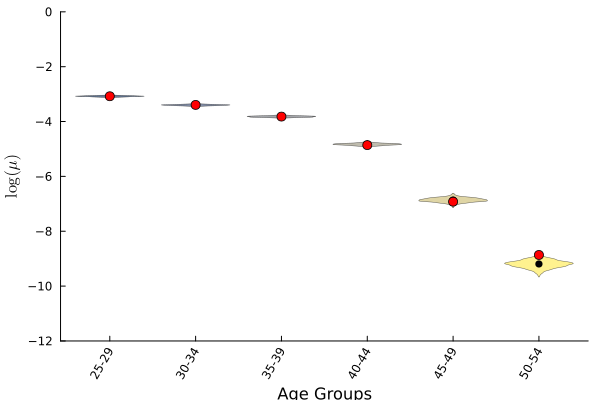

In [12]:
gofmodelA1

In [14]:
savefig(gofmodelA1, dir * "GOF/gofmodelA1.png")
savefig(gofmodelA2, dir * "GOF/gofmodelA2.png")
savefig(gofmodelA3, dir * "GOF/gofmodelA3.png")
savefig(gofmodelA4, dir * "GOF/gofmodelA4.png")

savefig(gofmodelB1, dir * "GOF/gofmodelB1.png")
savefig(gofmodelB2, dir * "GOF/gofmodelB2.png")
savefig(gofmodelB3, dir * "GOF/gofmodelB3.png")
savefig(gofmodelB4, dir * "GOF/gofmodelB4.png")

savefig(gofmodelC1, dir * "GOF/gofmodelC1.png")
savefig(gofmodelC2, dir * "GOF/gofmodelC2.png")
savefig(gofmodelC3, dir * "GOF/gofmodelC3.png")
savefig(gofmodelC4, dir * "GOF/gofmodelC4.png")




"/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Fertility/ModellingF/Output/GOF/gofmodelC4.png"